<a href="https://colab.research.google.com/github/Jaythan07/Time-Series-Forecasting-using-Facebook-Prophet/blob/main/Time_series_prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting using Facebook Prophet

Forecasting with time series models can be used by businesses for many purposes, for example, to optimise sales, improve supply chain planning and many other. There are many different techniques you can use solve such problems.

In this article we'll use Prophet, a open-source package developed by Facebook to perform time series forecasting.

## Introduction

[Prophet](https://github.com/facebook/prophet) is an open-source package for univariate (one variable) time series forecasting developed by Facebook.

Prophet implements additive time series forecasting model, and the implementation supports trends, seasonality, and holidays. This package provides two interfaces, including R and Python. We will focus on the Python interface.

## Installation

Prophet can be installed using either command prompt or Anaconda prompt using pip as shown below. Prophet depends on a Python module called `pystan`.

```bash
pip install fbprophet
```

Now we have Prophet installed, let's select a dataset we can use to explore using the package.

## Avocado Dataset

We will use the Avocado [dataset](https://www.kaggle.com/neuromusic/avocado-prices). The data set includes information about the prices of (Hass) avocados and the amount sold (of different kinds) at different points in time.

Columns of interest are:
* `Date`: date of the observation
* `AveragePrice`: average price of a single avocado
* `Total Volume`: total number of avocados sold
* `type`: whether the price/amount is for conventional or organic
* `4046`: total number of small avocados sold (PLU 4046)
* `4225`: total number of medium avocados sold (PLU 4225)
* `4770`: total number of large avocados sold (PLU 4770)
* `Region`: the city or region of the observation

Let's load and explore the dataset.

## Import Packages


In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet
import numpy as np
import pandas as pd

## Loading dataset

In [ ]:
df = pd.read_csv("/content/avocado.csv")

In [ ]:
df.head(2)

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany


For simplicity, we'll only select the `AveragePrice` prices for `conventional` avocodos from dataset

In [ ]:
df_avocado = df[(df.type == 'conventional') ]

In [ ]:
df_avocado['Date'] = pd.to_datetime(df_avocado['Date'])
df_avocado = df_avocado.sort_values("Date")

<ipython-input-11-6cd494499dd5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_avocado['Date'] = pd.to_datetime(df_avocado['Date'])


## Dataset for Prophet

Prophet is expecting columns to have specific names, `ds` for the temporal part and `y` for the value part. We'll prepare data according to that.

In [ ]:
df_avocado = df_avocado[['Date', 'AveragePrice']].reset_index(drop=True)
df_avocado.rename(columns={'Date':'ds', 'AveragePrice':'y'}, inplace=True)

In [ ]:
df_avocado.head(2)

,ds,y
0,2015-01-04,0.93
1,2015-01-04,1.10


It's always a good idea to plot the data to get a first impression on what we are dealing with. We'll plot.ly for plotting  charts.

In [ ]:
import plotly.express as px

fig = px.line(df_avocado, x='ds', y='y', title='Line Plot of Avocado Dataset')
fig.show()

We can see the trend in average price over time. Such patterns we expect the forecast model should consider.

Now we are familiar with the dataset, let's explore how we can make a use of the Prophet package to make forecasts.

## Forecast avocodos average price with Prophet

Let's start by fitting a model on the dataset

### Fit Prophet model

Now let's create the `Prophet` instance with all default values, fit the dataset.

In [ ]:
m = Prophet()
m.fit(df_avocado)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnpo3r3oo/w7ix1qc3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnpo3r3oo/ng0jp42e.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29662', 'data', 'file=/tmp/tmpnpo3r3oo/w7ix1qc3.json', 'init=/tmp/tmpnpo3r3oo/ng0jp42e.json', 'output', 'file=/tmp/tmpnpo3r3oo/prophet_modelokrsmds9/prophet_model-20250417153951.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:39:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:39:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


### Make future prediction

For predicting the values using Prophet, we need to create a dataframe containing the dates for which we want to make the predictions.

We'll use `make_future_dataframe()` to specify the number of days to extend into the future. By default it includes dates from the history.

In [ ]:
future = m.make_future_dataframe(periods=365)
future.tail(2)

,ds
532,2019-03-24
533,2019-03-25


Now, Create the forecast object which will hold all of the resulting data from the forecast.

In [ ]:
forecast = m.predict(future)

When listing the forecast dataframe we get:

In [ ]:
forecast.head(2)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-04,1.216815,0.835335,1.384989,1.216815,1.216815,-0.112454,-0.112454,-0.112454,-0.112454,-0.112454,-0.112454,0.0,0.0,0.0,1.104361
1,2015-01-11,1.212127,0.839967,1.391822,1.212127,1.212127,-0.094593,-0.094593,-0.094593,-0.094593,-0.094593,-0.094593,0.0,0.0,0.0,1.117533


The `yhat` contains the predictions and then you have lower and upper bands of the predictions.

### Plotting forecast data

Here, Prophet provides convenience methods for plotting.

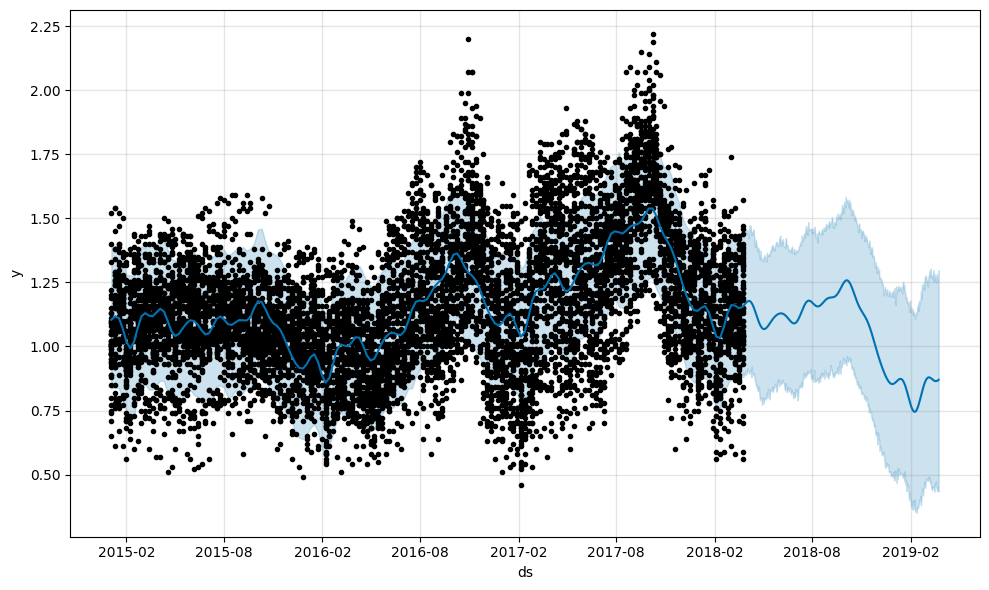

In [ ]:
# Simple plot
fig = m.plot(forecast)

## Using plot.ly
# from fbprophet.plot import plot_plotly

# plot_plotly(m, forecast)

You can also add change-points (where the trend model is shifting) to the plot like this:

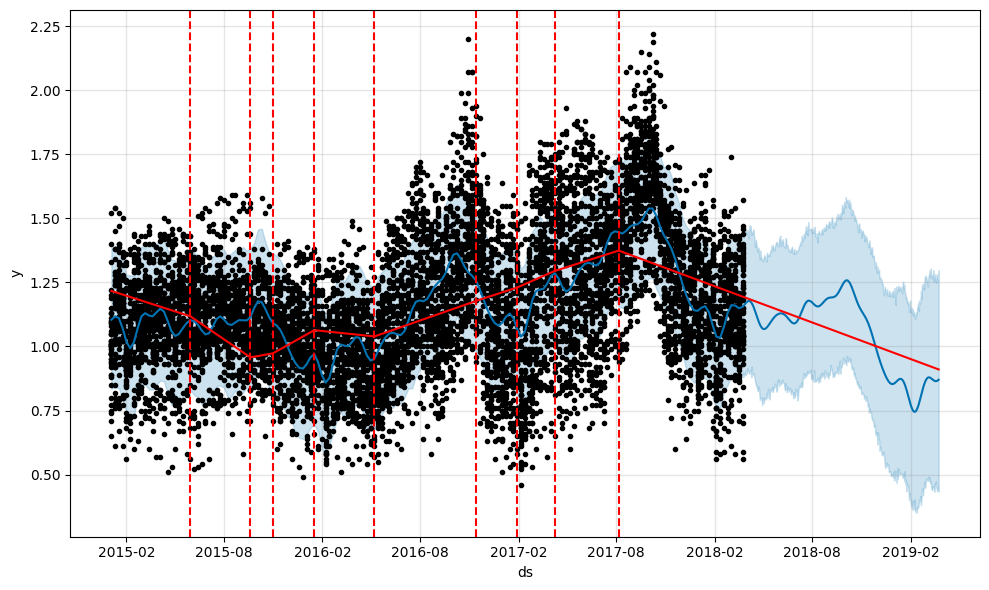

In [ ]:
# Simple plot

from prophet.plot import add_changepoints_to_plot

fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)

## Using plot.ly
# from fbprophet.plot import plot_plotly

# plot_plotly(m, forecast, changepoints=True)

### Plotting the forecasted components

We can also plot all the components that make up the model: trend, seasonality

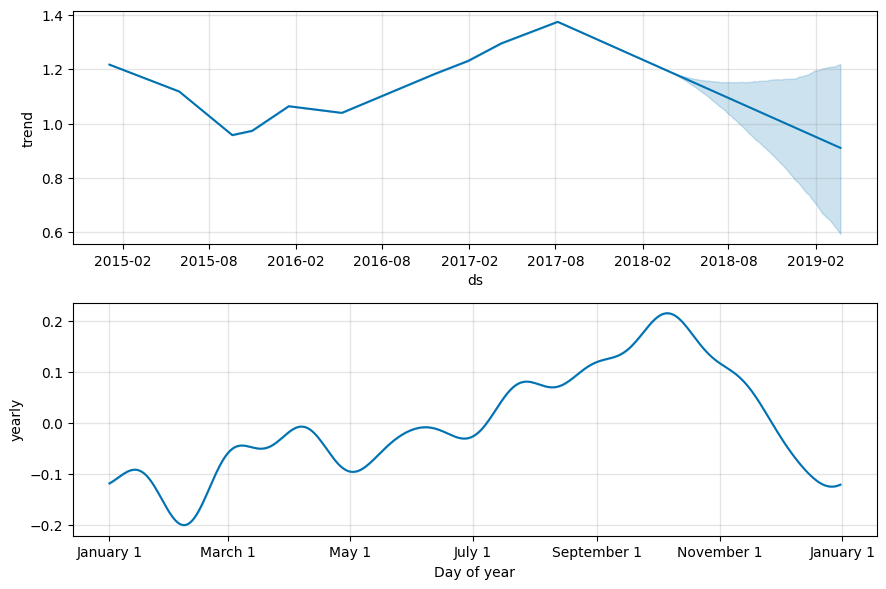

In [ ]:
# from fbprophet.plot import plot_components_plotly

# ## Using plot.ly
# plot_components_plotly(m, forecast)

# simple plot
fig = m.plot_components(forecast)

Prophet learns that price is usually going up from July to December.

## Cross Validaton

In order for us to find out how our model performs and know if we are making progress we need some kind of validation. Prophet includes functionality for time series cross validation to measure forecast error using historical data.  

This cross validation procedure can be done automatically for a range of historical cutoffs using the `cross_validation` function. We specify,

* `horizon` - the forecast horizon
* `initial` - the size of the initial training period
* `period` - the spacing between cutoff dates

By default, the `initial` training period is set to three times the `horizon`, and cutoffs (`period`) are made every half a horizon.

The resulting dataframe can now be used to compute error measures of `yhat` vs. `y`.

Here we do cross-validation to assess prediction performance on a horizon of 180 days, starting with 540 days of training data in the first cutoff and then making predictions every 31 days.

You can read more on Prophet Cross Validation [here](https://facebook.github.io/prophet/docs/diagnostics.html).

In [ ]:
from prophet.diagnostics import cross_validation

df_cv = cross_validation(m, initial='540 days', period='31 days', horizon = '180 days')

INFO:prophet:Making 15 forecasts with cutoffs between 2016-07-19 00:00:00 and 2017-09-26 00:00:00


  0%|          | 0/15 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpnpo3r3oo/j3u8tbqb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnpo3r3oo/46ux6q96.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=13588', 'data', 'file=/tmp/tmpnpo3r3oo/j3u8tbqb.json', 'init=/tmp/tmpnpo3r3oo/46ux6q96.json', 'output', 'file=/tmp/tmpnpo3r3oo/prophet_model6h_cs0jl/prophet_model-20250417154413.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:44:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:44:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnpo3r3oo/3lm2qtw7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpnpo3r3oo/u8cpbb15.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

## Performance Metrics

Prophet comes with some built-in performance metrics, The performance metrics available are:

* `mse`: mean absolute error
* `rmse`: mean squared error
* `mae`: Mean average error
* `mape`: Mean average percentage error
* `mdape`: Median average percentage error

The code for validating and gathering performance metrics is shown below:

In [ ]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head(2)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,19 days,0.076489,0.276566,0.224016,0.191085,0.147774,0.180213,0.608614
1,20 days,0.076649,0.276856,0.224063,0.190967,0.147774,0.179995,0.608525


Cross validation performance metrics can be visualized with `plot_cross_validation_metric`, here shown for MAPE. Dots show the absolute percent error for each prediction in df_cv. The blue line shows the MAPE.

It shows that errors around 20% are typical for predictions 20 days into the future, and that errors increase up to around 30% for predictions 180 days into the future.

/usr/local/lib/python3.11/dist-packages/prophet/plot.py:546: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

/usr/local/lib/python3.11/dist-packages/prophet/plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



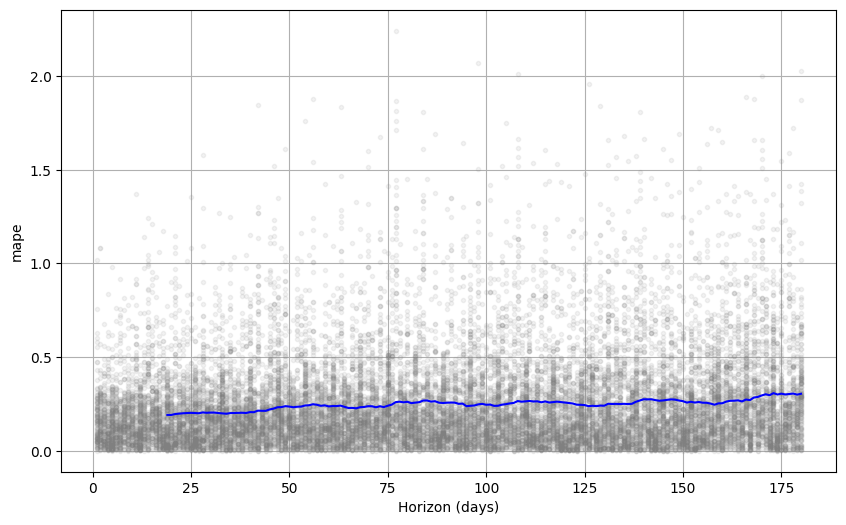

In [ ]:
from prophet.plot import plot_cross_validation_metric

fig = plot_cross_validation_metric(df_cv, metric='mape')

## Improvements

You can further improve your models by adding holidays, adding extra regressors and by tuning hyperparameters. Learn more from [here](https://facebook.github.io/prophet/docs/quick_start.html#python-api).

## Saving/Loading Prophet models

Here Prophet provides the built-in serialization functions to serialize the model to json:

In [ ]:
import os
import json
from prophet.serialize import model_to_json, model_from_json

# Make sure 'models' directory exists
os.makedirs('models', exist_ok=True)

# Save the model
with open('models/model_avocados_avg_prices.json', 'w') as fout:
    json.dump(model_to_json(m), fout)
